In [66]:
import numpy as np
from scipy.optimize import root
import matplotlib.pyplot as plt
import pandas as pd

# Kondo mean-field

In [5]:
class HybridizationKondoMF:
    """
    Mean-field solver for the hybridization Kondo lattice theory
    with fermionic spinons on a square lattice at fixed hole doping p.

    Unknowns:
        x = [chi1, phi, lam, mu]

    Equations:
        1) spinon constraint
        2) bond equation
        3) hybridization equation
        4) conduction density equation
    """

    def __init__(
        self,
        t=1.0,
        J1=0.3,
        JK=4.0,
        p=0.1,
        T=0.05,
        nk=120,
    ):
        self.t = float(t)
        self.J1 = float(J1)
        self.JK = float(JK)
        self.p = float(p)
        self.T = float(T)
        self.nk = int(nk)

        self.z1 = 4

        kx = np.linspace(-np.pi, np.pi, self.nk, endpoint=False)
        ky = np.linspace(-np.pi, np.pi, self.nk, endpoint=False)
        self.kx, self.ky = np.meshgrid(kx, ky, indexing="ij")

        self.gamma1 = 2.0 * (np.cos(self.kx) + np.cos(self.ky))
        self.eps_c_bare = -self.t * self.gamma1
        self.nk_tot = self.nk * self.nk

    def set_JK(self, JK):
        self.JK = float(JK)

    def fermi(self, E):
        if self.T <= 0:
            return (E < 0).astype(float)
        x = np.clip(E / self.T, -700.0, 700.0)
        return 1.0 / (np.exp(x) + 1.0)

    def dispersions(self, chi1, lam, mu):
        eps_c = self.eps_c_bare - mu
        eps_f = lam - 0.5 * self.J1 * chi1 * self.gamma1
        return eps_c, eps_f

    def observables(self, chi1, phi, lam, mu):
        eps_c, eps_f = self.dispersions(chi1, lam, mu)

        avg_ff = 0.0
        avg_cc = 0.0
        avg_cf = 0.0
        avg_gamma_ff = 0.0

        for ix in range(self.nk):
            for iy in range(self.nk):
                hk = np.array(
                    [
                        [eps_c[ix, iy], phi],
                        [phi, eps_f[ix, iy]],
                    ],
                    dtype=float,
                )

                evals, evecs = np.linalg.eigh(hk)
                occ = self.fermi(evals)
                rho = evecs @ np.diag(occ) @ evecs.T

                cc = rho[0, 0]   # <c^dag c> per spin
                ff = rho[1, 1]   # <f^dag f> per spin
                cf = rho[0, 1]   # <c^dag f> per spin

                avg_cc += cc
                avg_ff += ff
                avg_cf += cf
                avg_gamma_ff += self.gamma1[ix, iy] * ff

        norm = float(self.nk_tot)
        spin_factor = 2.0

        return {
            "ff": spin_factor * avg_ff / norm,
            "cc": spin_factor * avg_cc / norm,
            "cf": spin_factor * avg_cf / norm,
            "gamma_ff": spin_factor * avg_gamma_ff / norm,
        }

    def equations(self, x):
        chi1, phi, lam, mu = x
        obs = self.observables(chi1, phi, lam, mu)

        eq_constraint = obs["ff"] - 1.0
        eq_bond = chi1 - obs["gamma_ff"] / self.z1
        eq_hybrid = phi + 0.5 * self.JK * obs["cf"]
        eq_density = obs["cc"] - (1.0 - self.p)

        return np.array([eq_constraint, eq_bond, eq_hybrid, eq_density], dtype=float)

    def solve(self, x0=None, tol=1e-10, method="hybr"):
        if x0 is None:
            x0 = np.array([0.1, 0.2, 0.0, 0.0], dtype=float)
        else:
            x0 = np.array(x0, dtype=float)

        sol = root(self.equations, x0, method=method, tol=tol)
        if not sol.success:
            raise RuntimeError(f"Root solve failed: {sol.message}")

        chi1, phi, lam, mu = sol.x
        obs = self.observables(chi1, phi, lam, mu)

        residuals = self.equations(sol.x)
        fden = self.free_energy_density(chi1, phi, lam, mu)

        return {
            "success": sol.success,
            "message": sol.message,
            "x": sol.x.copy(),
            "chi1": chi1,
            "phi": phi,
            "lambda": lam,
            "mu": mu,
            "nc": obs["cc"],
            "nf": obs["ff"],
            "cf": obs["cf"],
            "p": self.p,
            "JK": self.JK,
            "constraint_residual": residuals[0],
            "bond_residual": residuals[1],
            "hybrid_residual": residuals[2],
            "density_residual": residuals[3],
            "free_energy_density": fden,
        }

    def free_energy_density(self, chi1, phi, lam, mu):
        eps_c, eps_f = self.dispersions(chi1, lam, mu)

        root_term = np.sqrt(0.25 * (eps_c - eps_f) ** 2 + phi ** 2)
        eplus = 0.5 * (eps_c + eps_f) + root_term
        eminus = 0.5 * (eps_c + eps_f) - root_term

        e0 = -lam + 0.5 * self.z1 * self.J1 * chi1 * chi1 + (2.0 / self.JK) * phi * phi

        if self.T <= 0:
            ff = 2.0 * np.mean(eplus * (eplus < 0) + eminus * (eminus < 0))
        else:
            xplus = np.clip(-eplus / self.T, -700.0, 700.0)
            xminus = np.clip(-eminus / self.T, -700.0, 700.0)
            ff = -2.0 * self.T * np.mean(
                np.log1p(np.exp(xplus)) + np.log1p(np.exp(xminus))
            )

        return e0 + ff



if __name__ == "__main__":
    solver = HybridizationKondoMF(
        t=1.0,
        J1=0.5,
        JK=7,
        p=0.25,
        T=0.05,
        nk=120,
    )

    # Initial guess: [chi1, phi, lambda, mu]
    x0 = [-0.005, 3, 1.6, -3]

    sol = solver.solve(x0=x0)

    print("Self-consistent solution")
    print("------------------------")
    print(f"chi1      = {sol['chi1']:.10f}")
    print(f"phi       = {sol['phi']:.10f}")
    print(f"lambda    = {sol['lambda']:.10f}")
    print(f"mu        = {sol['mu']:.10f}")
    print(f"n_c       = {sol['nc']:.10f}")
    print(f"n_f       = {sol['nf']:.10f}")
    print(f"<c^dag f> = {sol['cf']:.10f}")
    print(f"p         = {sol['p']:.10f}")
    print()
    print("Residuals")
    print("---------")
    print(f"constraint = {sol['constraint_residual']:.3e}")
    print(f"bond       = {sol['bond_residual']:.3e}")
    print(f"hybrid     = {sol['hybrid_residual']:.3e}")
    print(f"density    = {sol['density_residual']:.3e}")
    print()

    fden = solver.free_energy_density(
        sol["chi1"], sol["phi"], sol["lambda"], sol["mu"]
    )
    print(f"Free-energy density = {fden:.10f}")

Self-consistent solution
------------------------
chi1      = 0.0177677103
phi       = 2.9200957499
lambda    = 1.5398415005
mu        = -2.9205789437
n_c       = 0.7500000000
n_f       = 1.0000000000
<c^dag f> = -0.8343130714
p         = 0.2500000000

Residuals
---------
constraint = 9.326e-15
bond       = 1.964e-15
hybrid     = 0.000e+00
density    = -1.843e-14

Free-energy density = -0.9821113656


In [ ]:
t = 1.0
J1 = 0.5
p = 0.25
T = 0.01
nk = 120

JK_values = np.linspace(7.0, 0.5, 100)   # start large JK and go down

solver = HybridizationKondoMF(t=t, J1=J1, JK=JK_values[0], p=p, T=T, nk=nk)

results = []

# initial guess for the first point
x_guess = [-0.005, 3, 1.6, -3]

for i, JK in enumerate(JK_values):
    solver.set_JK(JK)

    try:
        sol = solver.solve(x0=x_guess)
        results.append({
            "JK": sol["JK"],
            "chi1": sol["chi1"],
            "phi": sol["phi"],
            "lambda": sol["lambda"],
            "mu": sol["mu"],
            "nc": sol["nc"],
            "nf": sol["nf"],
            "cf": sol["cf"],
            "free_energy_density": sol["free_energy_density"],
            "constraint_residual": sol["constraint_residual"],
            "bond_residual": sol["bond_residual"],
            "hybrid_residual": sol["hybrid_residual"],
            "density_residual": sol["density_residual"],
            "success": True,
        })

        # use previous solution as next initial guess
        x_guess = sol["x"].copy()

        print(
            f"[{i+1:02d}/{len(JK_values)}] JK={JK:.4f}  "
            f"phi={sol['phi']:.6f}  chi1={sol['chi1']:.6f}  "
            f"lambda={sol['lambda']:.6f}  mu={sol['mu']:.6f}"
        )

    except Exception as err:
        results.append({
            "JK": JK,
            "chi1": np.nan,
            "phi": np.nan,
            "lambda": np.nan,
            "mu": np.nan,
            "nc": np.nan,
            "nf": np.nan,
            "cf": np.nan,
            "free_energy_density": np.nan,
            "constraint_residual": np.nan,
            "bond_residual": np.nan,
            "hybrid_residual": np.nan,
            "density_residual": np.nan,
            "success": False,
            "error": str(err),
        })

        # reset guess a bit if one point fails
        x_guess = np.array([0.1, max(0.05, JK / 10.0), 0.0, 0.0], dtype=float)

        print(f"[{i+1:02d}/{len(JK_values)}] JK={JK:.4f}  FAILED: {err}")




print("\nFinished sweep.")
print(f"Successful points: {sum(r['success'] for r in results)} / {len(results)}")

[01/100] JK=7.0000  phi=2.921803  chi1=0.021488  lambda=1.537626  mu=-2.923940
[02/100] JK=6.9343  phi=2.892366  chi1=0.020630  lambda=1.515419  mu=-2.893916
[03/100] JK=6.8687  phi=2.862911  chi1=0.019757  lambda=1.493257  mu=-2.863941
[04/100] JK=6.8030  phi=2.833438  chi1=0.018868  lambda=1.471141  mu=-2.834015
[05/100] JK=6.7374  phi=2.803946  chi1=0.017964  lambda=1.449072  mu=-2.804142
[06/100] JK=6.6717  phi=2.774436  chi1=0.017044  lambda=1.427051  mu=-2.774320
[07/100] JK=6.6061  phi=2.744905  chi1=0.016107  lambda=1.405081  mu=-2.744553
[08/100] JK=6.5404  phi=2.715355  chi1=0.015154  lambda=1.383162  mu=-2.714841
[09/100] JK=6.4747  phi=2.685784  chi1=0.014183  lambda=1.361296  mu=-2.685185
[10/100] JK=6.4091  phi=2.656192  chi1=0.013194  lambda=1.339484  mu=-2.655588
[11/100] JK=6.3434  phi=2.626578  chi1=0.012188  lambda=1.317728  mu=-2.626051
[12/100] JK=6.2778  phi=2.596942  chi1=0.011162  lambda=1.296029  mu=-2.596575
[13/100] JK=6.2121  phi=2.567283  chi1=0.010118  lam

In [ ]:
df = pd.DataFrame(results)
# Save to CSV
df.to_csv("Kondo_hybridization.csv", index=False)

In [73]:
df["JK"]

0     7.000000
1     6.934343
2     6.868687
3     6.803030
4     6.737374
        ...   
95    0.762626
96    0.696970
97    0.631313
98    0.565657
99    0.500000
Name: JK, Length: 100, dtype: float64

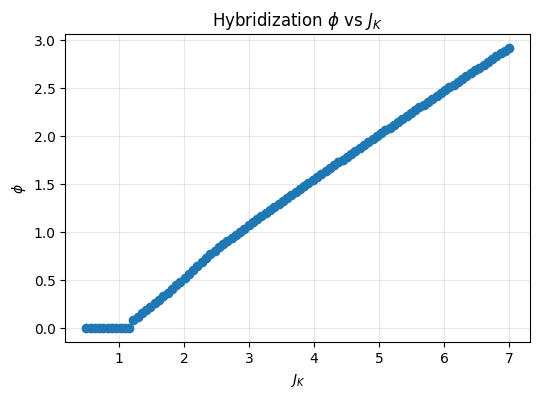

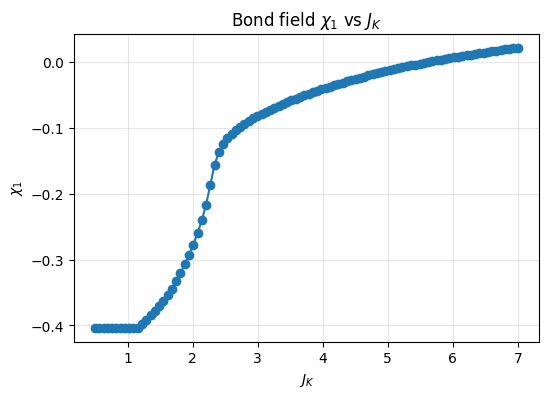

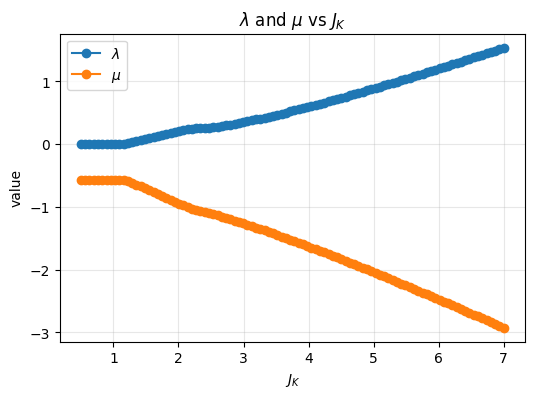

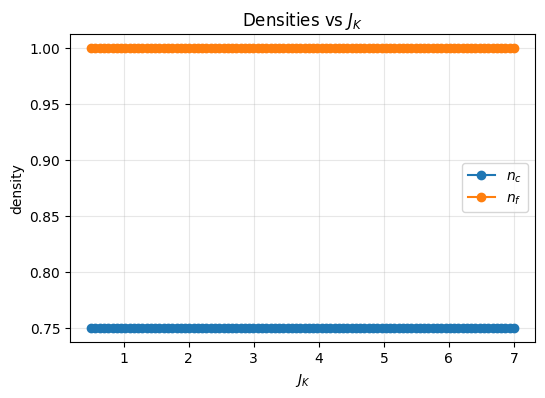

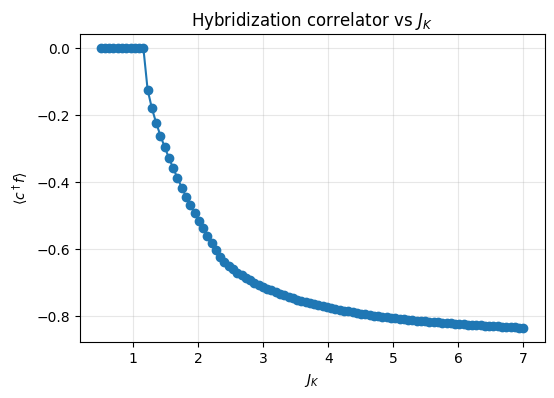

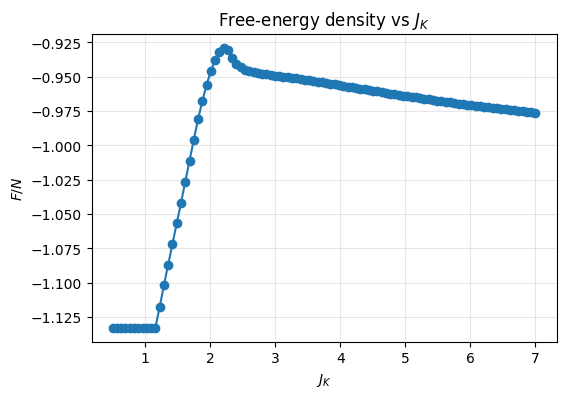

In [74]:
results = pd.read_csv("Kondo_hybridization.csv")
# Convert columns to numpy arrays for plotting / analysis
JK_list = results["JK"].to_numpy(dtype=float)
chi1_list = results["chi1"].to_numpy(dtype=float)
phi_list = results["phi"].to_numpy(dtype=float)
lambda_list = results["lambda"].to_numpy(dtype=float)
mu_list = results["mu"].to_numpy(dtype=float)
nc_list = results["nc"].to_numpy(dtype=float)
nf_list = results["nf"].to_numpy(dtype=float)
cf_list = results["cf"].to_numpy(dtype=float)
f_list = results["free_energy_density"].to_numpy(dtype=float)



figsize = (6, 4)

plt.figure(figsize=figsize)
plt.plot(JK_list, phi_list, "o-")
plt.xlabel(r"$J_K$")
plt.ylabel(r"$\phi$")
plt.title(r"Hybridization $\phi$ vs $J_K$")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=figsize)
plt.plot(JK_list, chi1_list, "o-")
plt.xlabel(r"$J_K$")
plt.ylabel(r"$\chi_1$")
plt.title(r"Bond field $\chi_1$ vs $J_K$")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=figsize)
plt.plot(JK_list, lambda_list, "o-", label=r"$\lambda$")
plt.plot(JK_list, mu_list, "o-", label=r"$\mu$")
plt.xlabel(r"$J_K$")
plt.ylabel("value")
plt.title(r"$\lambda$ and $\mu$ vs $J_K$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=figsize)
plt.plot(JK_list, nc_list, "o-", label=r"$n_c$")
plt.plot(JK_list, nf_list, "o-", label=r"$n_f$")
plt.xlabel(r"$J_K$")
plt.ylabel("density")
plt.title(r"Densities vs $J_K$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=figsize)
plt.plot(JK_list, cf_list, "o-")
plt.xlabel(r"$J_K$")
plt.ylabel(r"$\langle c^\dagger f \rangle$")
plt.title(r"Hybridization correlator vs $J_K$")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=figsize)
plt.plot(JK_list, f_list, "o-")
plt.xlabel(r"$J_K$")
plt.ylabel(r"$F/N$")
plt.title(r"Free-energy density vs $J_K$")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
data = np.column_stack([JK_list, -0.5*chi1_list/2])
np.savetxt("jk_phi.csv", data, delimiter=",")

# Kondo three states mean-field

In [79]:
import numpy as np
from scipy.optimize import root


class KondoMF:
    """
    Mean-field solver for the 3-state large-J_K Kondo lattice theory
    on a square lattice at fixed hole doping p.

    Unknowns:
        x = [b, lam, chi1, mu]

    Equations:
        1) constraint
        2) singlet saddle-point equation
        3) bond equation
        4) density equation b^2 = 1 - p
    """

    def __init__(
        self,
        t=1.0,
        J1=0.3,
        JK=4.0,
        p=0.1,
        T=0.05,
        nk=200,
    ):
        self.t = float(t)
        self.J1 = float(J1)
        self.JK = float(JK)
        self.p = float(p)
        self.T = float(T)
        self.nk = int(nk)
        print(self.JK)

        self.z1 = 4  # square lattice coordination number

        kx = np.linspace(-np.pi, np.pi, self.nk, endpoint=False)
        ky = np.linspace(-np.pi, np.pi, self.nk, endpoint=False)
        self.kx, self.ky = np.meshgrid(kx, ky, indexing="ij")

        self.gamma1 = 2.0 * (np.cos(self.kx) + np.cos(self.ky))
        self.eps_c = -self.t * self.gamma1

        self.nk_tot = self.nk * self.nk

    def fermi(self, E):
        """Stable Fermi function."""
        if self.T <= 0:
            return (E < 0).astype(float)

        x = E / self.T
        x = np.clip(x, -700.0, 700.0)
        return 1.0 / (np.exp(x) + 1.0)

    def dispersion(self, b, lam, chi1):
        """
        E_k = lambda - (b^2/2) eps_c - (J1/2) Gamma1(k) chi1
        """
        return lam - 0.5 * b * b * self.eps_c - 0.5 * self.J1 * self.gamma1 * chi1

    def equations(self, x):
        b, lam, chi1, mu = x

        # Keep b physical during iteration as much as possible
        # The root solver can still try unphysical values, but this helps.
        Ek = self.dispersion(b, lam, chi1)
        nf = self.fermi(Ek)

        # spin sum: sigma = up, down
        spin_factor = 2.0

        avg_nf = spin_factor * np.mean(nf)
        avg_eps_nf = spin_factor * np.mean(self.eps_c * nf)
        avg_gamma_nf = spin_factor * np.mean(self.gamma1 * nf)

        eq_constraint = b * b + avg_nf - 1.0

        eq_singlet = (
            lam - 0.75 * self.JK - mu
            - 0.5 * avg_eps_nf
        )

        eq_bond = chi1 - avg_gamma_nf / self.z1

        eq_doping = b * b - (1.0 - self.p)

        return np.array([eq_constraint, eq_singlet, eq_bond, eq_doping], dtype=float)

    def solve(self, x0=None, tol=1e-10, method="hybr"):
        if x0 is None:
            b0 = np.sqrt(max(1.0 - self.p, 1e-8))
            lam0 = 0.75 * self.JK
            chi10 = 0.1
            mu0 = 0.0
            x0 = np.array([b0, lam0, chi10, mu0], dtype=float)
        else:
            x0 = np.array(x0, dtype=float)

        sol = root(self.equations, x0, method=method, tol=tol)

        if not sol.success:
            raise RuntimeError(f"Root solve failed: {sol.message}")

        b, lam, chi1, mu = sol.x
        Ek = self.dispersion(b, lam, chi1)
        nf = self.fermi(Ek)

        results = {
            "success": sol.success,
            "message": sol.message,
            "b": b,
            "lambda": lam,
            "chi1": chi1,
            "mu": mu,
            "nc": b * b,
            "p": self.p,
            "constraint_residual": self.equations(sol.x)[0],
            "singlet_residual": self.equations(sol.x)[1],
            "bond_residual": self.equations(sol.x)[2],
            "doping_residual": self.equations(sol.x)[3],
            "Ek_min": float(np.min(Ek)),
            "Ek_max": float(np.max(Ek)),
            "nf_mean_per_spin": float(np.mean(nf)),
        }
        return results

    def free_energy_density(self, b, lam, chi1, mu):
        """
        Free-energy density f = F / N
        Useful for comparing multiple solutions.

        E0/N = lambda(b^2 - 1) - mu b^2 - 3JK b^2 / 4 + z1 J1 chi1^2 / 2
        F_f/N = -2 T < ln(1 + exp(-Ek/T)) >
        """
        Ek = self.dispersion(b, lam, chi1)

        e0 = (
            lam * (b * b - 1.0)
            - mu * b * b
            - 0.75 * self.JK * b * b
            + 0.5 * self.z1 * self.J1 * chi1 * chi1
        )

        if self.T <= 0:
            ff = 2.0 * np.mean(Ek * (Ek < 0))
        else:
            x = np.clip(-Ek / self.T, -700.0, 700.0)
            ff = -2.0 * self.T * np.mean(np.log1p(np.exp(x)))

        return e0 + ff




In [46]:
if __name__ == "__main__":
    # Example parameters
    solver = KondoMF(
        t=1.0,
        J1=0.5,
        JK=4,
        p=0.25,   # hole doping
        T=0.05,
        nk=200,
    )

    # Initial guess: [b, lambda, chi1, mu]
    x0 = [np.sqrt(1.0 - solver.p), 1.1, 0.2, -2.0]

    sol = solver.solve(x0=x0)

    print("Self-consistent solution")
    print("------------------------")
    print(f"b       = {sol['b']:.10f}")
    print(f"lambda  = {sol['lambda']:.10f}")
    print(f"chi1    = {sol['chi1']:.10f}")
    print(f"mu      = {sol['mu']:.10f}")
    print(f"n_c     = {sol['nc']:.10f}")
    print(f"p       = {sol['p']:.10f}")
    print()
    print("Residuals")
    print("---------")
    print(f"constraint = {sol['constraint_residual']:.3e}")
    print(f"singlet    = {sol['singlet_residual']:.3e}")
    print(f"bond       = {sol['bond_residual']:.3e}")
    print(f"doping     = {sol['doping_residual']:.3e}")
    print()
    fden = solver.free_energy_density(
        sol["b"], sol["lambda"], sol["chi1"], sol["mu"]
    )
    print(f"Free-energy density = {fden:.10f}")

4.0
Self-consistent solution
------------------------
b       = 0.8660254038
lambda  = 1.0994907407
chi1    = -0.2029357921
mu      = -2.3063808435
n_c     = 0.7500000000
p       = 0.2500000000

Residuals
---------
constraint = 0.000e+00
singlet    = -1.665e-16
bond       = 0.000e+00
doping     = -1.110e-16

Free-energy density = -0.8284088366


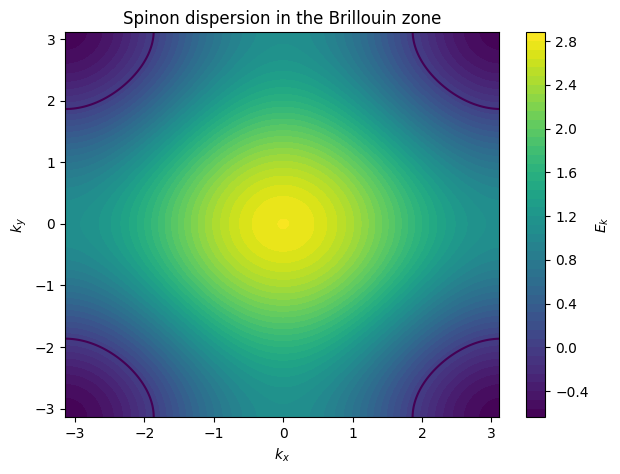

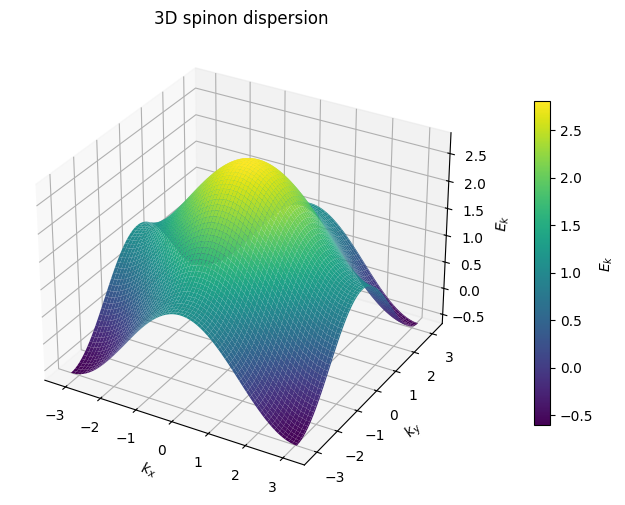

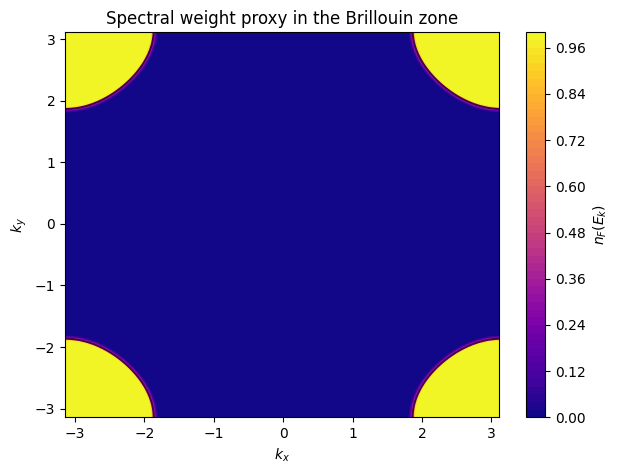

In [80]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- solved parameters ---
b = sol["b"]
lam = sol["lambda"]
chi1 = sol["chi1"]

# --- full BZ grid from solver ---
kx = solver.kx
ky = solver.ky
gamma1 = solver.gamma1
eps_c = solver.eps_c

# spinon dispersion on full 2D BZ
Ek = lam - 0.5 * b**2 * eps_c - 0.5 * solver.J1 * gamma1 * chi1

# spectral weight proxy: Fermi occupation
if solver.T <= 0:
    nf = (Ek < 0).astype(float)
else:
    x = np.clip(Ek / solver.T, -700.0, 700.0)
    nf = 1.0 / (np.exp(x) + 1.0)

# -----------------------------
# 1) 2D contour / heatmap of E_k
# -----------------------------
plt.figure(figsize=(7, 5))
plt.contourf(kx, ky, Ek, levels=50, cmap="viridis")
plt.colorbar(label=r"$E_k$")
plt.contour(kx, ky, Ek, levels=[0.0], linewidths=1.5)
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Spinon dispersion in the Brillouin zone")
plt.show()

# -----------------------------
# 2) 3D surface plot of E_k
# -----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(kx, ky, Ek, rstride=3, cstride=3, cmap="viridis", linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label=r"$E_k$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_zlabel(r"$E_k$")
ax.set_title("3D spinon dispersion")
plt.show()

# -----------------------------
# 3) 2D contour / heatmap of spectral weight proxy n_F(E_k)
# -----------------------------
plt.figure(figsize=(7, 5))
plt.contourf(kx, ky, nf, levels=50, cmap="plasma")
plt.colorbar(label=r"$n_F(E_k)$")
plt.contour(kx, ky, Ek, levels=[0.0], linewidths=1.5)
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Spectral weight proxy in the Brillouin zone")
plt.show()

In [84]:

# --- JK sweep settings ---
JK_values = np.linspace(7.0, 0.5, 100)   # start large JK and go down

# Base solver
solver = KondoMF(
    t=1.0,
    J1=0.5,
    JK=JK_values[0],
    p=0.25,
    T=0.01,
    nk=200,
)

results = []

# Initial guess for first point
x_guess = [np.sqrt(1.0 - solver.p), 1.1, 0.2, -2.0]

for i, JK in enumerate(JK_values):
    solver.JK = float(JK)

    try:
        sol = solver.solve(x0=x_guess)

        fden = solver.free_energy_density(
            sol["b"], sol["lambda"], sol["chi1"], sol["mu"]
        )

        results.append({
            "JK": JK,
            "b": sol["b"],
            "lambda": sol["lambda"],
            "chi1": sol["chi1"],
            "mu": sol["mu"],
            "nc": sol["nc"],
            "p": sol["p"],
            "free_energy_density": fden,
            "constraint_residual": sol["constraint_residual"],
            "singlet_residual": sol["singlet_residual"],
            "bond_residual": sol["bond_residual"],
            "doping_residual": sol["doping_residual"],
            "success": True,
        })

        # continuation: use previous solution as next initial guess
        x_guess = np.array(
            [sol["b"], sol["lambda"], sol["chi1"], sol["mu"]],
            dtype=float
        )

        print(
            f"[{i+1:02d}/{len(JK_values)}] JK={JK:.4f}  "
            f"b={sol['b']:.6f}  chi1={sol['chi1']:.6f}  "
            f"lambda={sol['lambda']:.6f}  mu={sol['mu']:.6f}"
        )

    except Exception as err:
        results.append({
            "JK": JK,
            "b": np.nan,
            "lambda": np.nan,
            "chi1": np.nan,
            "mu": np.nan,
            "nc": np.nan,
            "p": solver.p,
            "free_energy_density": np.nan,
            "constraint_residual": np.nan,
            "singlet_residual": np.nan,
            "bond_residual": np.nan,
            "doping_residual": np.nan,
            "success": False,
            "error": str(err),
        })

        # reset guess if one point fails
        x_guess = np.array(
            [np.sqrt(1.0 - solver.p), 0.75 * JK, 0.1, 0.0],
            dtype=float
        )

        print(f"[{i+1:02d}/{len(JK_values)}] JK={JK:.4f}  FAILED: {err}")

# arrays for plotting / export
JK_list = np.array([r["JK"] for r in results], dtype=float)
b_list = np.array([r["b"] for r in results], dtype=float)
lambda_list = np.array([r["lambda"] for r in results], dtype=float)
chi1_list = np.array([r["chi1"] for r in results], dtype=float)
mu_list = np.array([r["mu"] for r in results], dtype=float)
nc_list = np.array([r["nc"] for r in results], dtype=float)
f_list_1 = np.array([r["free_energy_density"] for r in results], dtype=float)

print("\nFinished sweep.")
print(f"Successful points: {sum(r['success'] for r in results)} / {len(results)}")

7.0
[01/100] JK=7.0000  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.559441
[02/100] JK=6.9343  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.510199
[03/100] JK=6.8687  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.460956
[04/100] JK=6.8030  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.411714
[05/100] JK=6.7374  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.362472
[06/100] JK=6.6717  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.313229
[07/100] JK=6.6061  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.263987
[08/100] JK=6.5404  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.214744
[09/100] JK=6.4747  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.165502
[10/100] JK=6.4091  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.116260
[11/100] JK=6.3434  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.067017
[12/100] JK=6.2778  b=0.866025  chi1=-0.204005  lambda=1.098570  mu=-4.017775
[13/100] JK=6.2121  b=0.866025  chi1=-0.204005  lambda=1.098

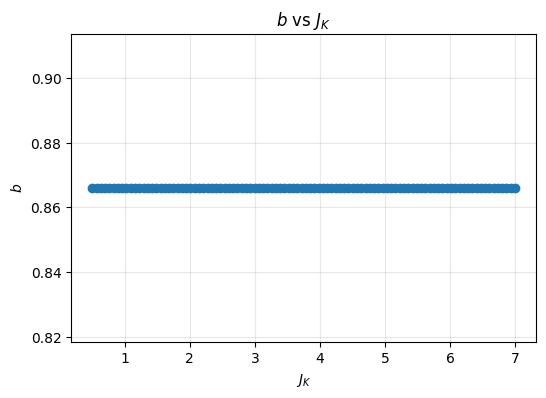

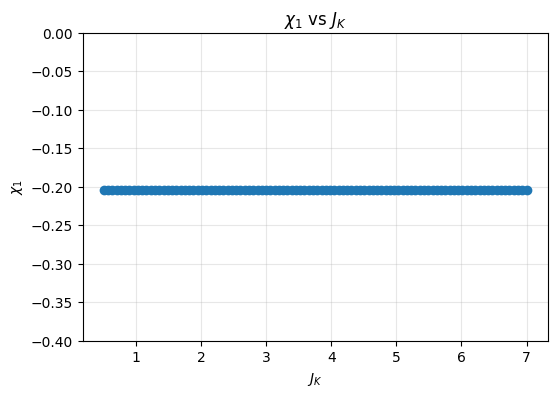

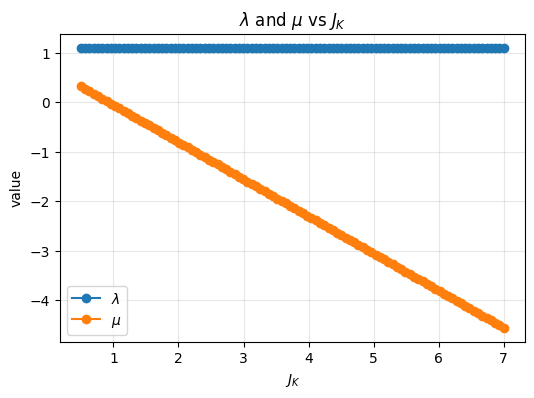

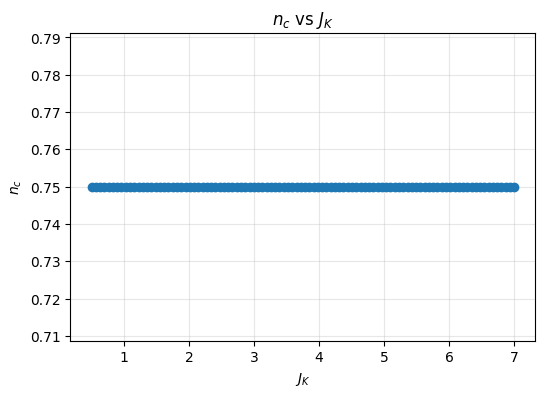

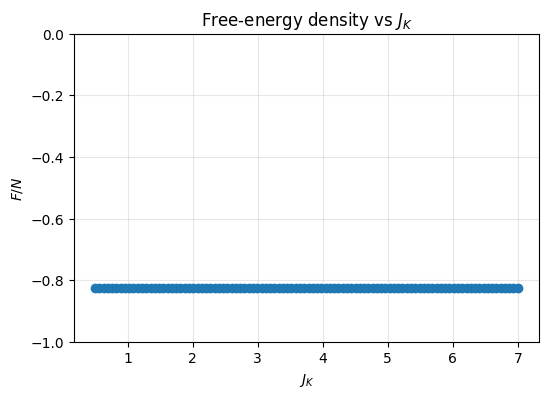

In [85]:
plt.figure(figsize=(6, 4))
plt.plot(JK_list, b_list, "o-")
plt.xlabel(r"$J_K$")
plt.ylabel(r"$b$")
plt.title(r"$b$ vs $J_K$")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(JK_list, chi1_list, "o-")
plt.xlabel(r"$J_K$")
plt.ylabel(r"$\chi_1$")
plt.title(r"$\chi_1$ vs $J_K$")
plt.ylim(-0.4, 0)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(JK_list, lambda_list, "o-", label=r"$\lambda$")
plt.plot(JK_list, mu_list, "o-", label=r"$\mu$")
plt.xlabel(r"$J_K$")
plt.ylabel("value")
plt.title(r"$\lambda$ and $\mu$ vs $J_K$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(JK_list, nc_list, "o-")
plt.xlabel(r"$J_K$")
plt.ylabel(r"$n_c$")
plt.title(r"$n_c$ vs $J_K$")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(JK_list, f_list_1, "o-")
plt.ylim(-1, 0)
plt.xlabel(r"$J_K$")
plt.ylabel(r"$F/N$")
plt.title(r"Free-energy density vs $J_K$")
plt.grid(True, alpha=0.3)
plt.show()

### comparison of two energies

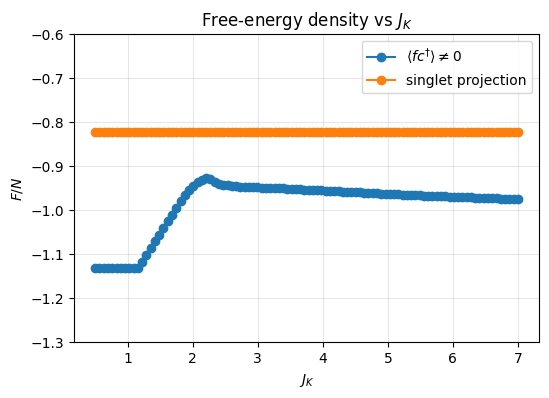

In [92]:
plt.figure(figsize=(6, 4))
plt.plot(JK_list, f_list, "o-",label=r"$\langle f c^\dag \rangle \neq 0$")
plt.plot(JK_list, f_list_1, "o-",label=r"singlet projection")
plt.ylim(-1, 0)
plt.xlabel(r"$J_K$")
plt.ylabel(r"$F/N$")
plt.ylim(-1.3,-0.6)
plt.title(r"Free-energy density vs $J_K$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()